## 1. FourCastNet v2 colab 教學版

## 在colab中模擬虛擬環境 (請使用google中的colab)

### download FCNV2 inference model, FCNv2 weight 

*  step0: 連到自己的google雲端(方便拿取輸出結果)
*  step1: git clone global_model_FCNV2_colab_education
*  step2: 下載FCNV2 weight

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
## Step1: download FCNV2 code from github
!git clone https://github.com/yungyun0721/global_model_FCNV2_colab_education.git

## Step2: download FCNV2 weight
%cd /content/global_model_FCNV2_colab_education
!wget 'https://api.ngc.nvidia.com/v2/models/nvidia/modulus/modulus_fcnv2_sm/versions/v0.2/files/fcnv2_sm.zip'
!unzip fcnv2_sm.zip
!mv fcnv2_sm FCNV2_weight
!rm -rf fcnv2_sm.zip


Mounted at /content/drive
Cloning into 'couple_FCNV2_LLAT'...
remote: Enumerating objects: 111, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 111 (delta 23), reused 104 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (111/111), 7.02 MiB | 6.00 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/couple_FCNV2_LLAT/global_model/FCNV2
--2026-05-05 10:17:47--  https://api.ngc.nvidia.com/v2/models/nvidia/modulus/modulus_fcnv2_sm/versions/v0.2/files/fcnv2_sm.zip
Resolving api.ngc.nvidia.com (api.ngc.nvidia.com)... 184.33.2.6, 52.36.127.163
Connecting to api.ngc.nvidia.com (api.ngc.nvidia.com)|184.33.2.6|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://xfiles.ngc.nvidia.com/org/nvidia/team/modulus/models/modulus_fcnv2_sm/versions/v0.2/files/fcnv2_sm.zip?ssec-algo=AES256&versionId=5EOzwamxNkLnRC.WfT.7pANCO1lZKGuV&ssec-key=Co7fmfofTkol8OmYOgvAcqgNqPzwUDdr22iJPpgPOQJHYsM

### 建置FCNV2需要的環境
*  Step1: 下載各種packages (colab 沒有的環境)

In [ ]:
# install the environment
!pip install -q -U xarray zarr gcsfs fsspec dask
!pip install -q metpy pysolar cartopy
!pip install -q torch_harmonics
!pip install -q ruamel.yaml
!pip install -q netcdf4 cfgrib pygrib
!pip install -q onnxruntime # if cpu
!pip install -U onnx onnxruntime-gpu # if gpu
!pip install -q xarray_regrid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.8/318.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 1.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.4/424.4 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 28.8 MB/s eta 0:00:00
   ━━

### 下載initial 資料

In [ ]:
# download the initial condition ERA5 (2026042700)
%cd /content/global_model_FCNV2_colab_education
!python download_ERA5_from_google_for_model_input.py --scheduled-time 2026080800 --save-folder input_data
# !python download_history_ncep_new.py --scheduled-time 2026081800 --save-folder input_data
# !python download_IFS_new.py --scheduled-time 2026081800 --save-folder input_data

/content/couple_FCNV2_LLAT
finish FCNV2 IC:2024102500
finish LLAT IC:2024102500
Traceback (most recent call last):
  File "/usr/lib/python3.12/weakref.py", line 666, in _exitfunc
    f()
  File "/usr/lib/python3.12/weakref.py", line 590, in __call__
    return info.func(*info.args, **(info.kwargs or {}))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gcsfs/core.py", line 406, in close_session
    asyn.sync(asyn.loop[0], session.close, timeout=0.1)
  File "/usr/local/lib/python3.12/dist-packages/fsspec/asyn.py", line 103, in sync
    raise return_result
  File "/usr/local/lib/python3.12/dist-packages/fsspec/asyn.py", line 56, in _runner
    result[0] = await coro
                ^^^^^^^^^^
  File "/usr/lib/python3.12/asyncio/tasks.py", line 520, in wait_for
    return await fut
           ^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/aiohttp/client.py", line 1360, in close
    await self._connector.close()
  File "/usr

### FCNV2資料展示 (可以跳過)

/content/couple_FCNV2_LLAT


Text(0, 0.5, 'Latitude')

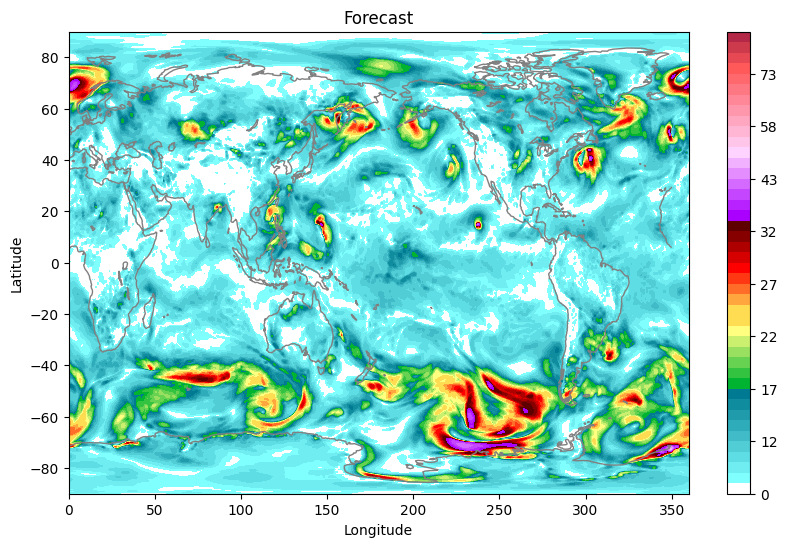

In [ ]:
%cd /content/global_model_FCNV2_colab_education
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

IC_data = np.load('/content/global_model_FCNV2_colab_education/input_data/ERA5_FCNV2_initial_condition.npy')
# IC_data = np.load('/content/global_model_FCNV2_colab_education/input_data/IFS_initial_condition.npy')
# IC_data = np.load('/content/global_model_FCNV2_colab_education/input_data/ncep_initial_condition.npy')
IC_flip = np.flip(IC_data, axis=1)
# variables order (73 variables)
ordering = [ "10u",  "10v", "100u", "100v",  "2t",  "sp",  "msl", "tcwv",
        "u50",  "u100", "u150", "u200", "u250", "u300", "u400", "u500", "u600", "u700", "u850", "u925", "u1000",
        "v50",  "v100", "v150", "v200", "v250", "v300", "v400", "v500", "v600", "v700", "v850", "v925", "v1000",
        "z50",  "z100", "z150", "z200", "z250", "z300", "z400", "z500", "z600", "z700", "z850", "z925", "z1000",
        "t50",  "t100", "t150", "t200", "t250", "t300", "t400", "t500", "t600", "t700", "t850", "t925", "t1000",
        "r50",  "r100", "r150", "r200", "r250", "r300", "r400", "r500", "r600", "r700", "r850", "r925", "r1000"]
index_ordering = 18
# index_ordering = 15
wsp_lev = [0,4,6,8,10,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,34,36,38,40,43,46,49,52,55,58,61,64,67,70,73,76,79,82,85]
wsp_color = ['#ffffff','#80ffff','#6fedf1','#5fdde4','#50cdd5','#40bbc7','#2facba','#1f9bac','#108c9f','#007a92',\
            '#00b432','#33c341','#67d251','#99e060','#cbf06f','#ffff80','#ffdd52','#ffdc52','#ffa63e','#ff6d29','#ff3713','#ff0000','#d70000','#af0000','#870000','#5f0000',\
            '#aa00ff','#b722fe','#c446ff','#d46aff','#e38dff','#f1b1ff','#ffd3ff',\
            '#ffc6ea','#ffb6d5','#ffa6c1','#ff97ac','#ff8798','#fe7884','#ff696e','#ff595a','#e74954','#cc3a4c','#b22846','#9a1941']

coast = pd.read_csv('/content/global_model_FCNV2_colab_education/plot/coast.csv')
coast_lon = coast.lon_map.copy()
coast_lon[coast.lon_map<0]=coast.lon_map[coast.lon_map<0]+360
coast_lon[(coast.lon_map<0) & (coast.lon_map>=-10)]=np.nan
coast.lon_map = coast_lon
# lon lat 850 hpa windspeed
IC_for_plot = np.sqrt(IC_flip[index_ordering,:,:]**2+IC_flip[index_ordering+13,:,:]**2)
xx, yy = np.meshgrid(np.linspace(0,359.75,1440), np.linspace(-90, 90, 721))
plt.figure(figsize=(10,6))
plt.plot(coast.lon_map,coast.lat_map,color='gray',linewidth=1)
plt.contourf(xx, yy, IC_for_plot, levels=wsp_lev, colors=wsp_color)
# plt.contourf(xx, yy, IC_flip[57,:,:], cmap="rainbow", levels=np.linspace(210,315,43))
plt.title('Forecast')
plt.colorbar()
plt.xlabel('Longitude');plt.ylabel('Latitude')

## FCNV2 預報
#### 目前使用GPU，預報120小時(每6小時一報)

In [ ]:
# FCNV2 predicting
%cd /content/global_model_FCNV2_colab_education
!python inference_FCNV2.py --FCNV2_IC_path input_data/ERA5_FCNV2_initial_condition.npy --save_folder output_data --fore_hour 120 #--FCNV2_device cpu

/content/couple_FCNV2_LLAT
initialize model ...
FCNV2 weight: global_model/FCNV2/weight, device: cuda
FCNV2 Model and weights are loaded.
LLAT.yaml: regional_model/DLAMPty/onnx/v57_5d.yaml, device: cpu
inference with ['CPUExecutionProvider']
Model and weights are loaded.
save folder: output_data_one_way
load IC data and save ...
FCNV2 IC path: input_data/FCNV2_2024102500_input.npy
LLAT IC path: input_data/LLAT_2024102500_input.nc
It needs to calc additional vars.
/usr/local/lib/python3.12/dist-packages/pysolar/numeric.py:62: UserWarning: no explicit representation of timezones available for np.datetime64
  dd = numpy.array(d, dtype='datetime64[D]')
/usr/local/lib/python3.12/dist-packages/pysolar/numeric.py:63: UserWarning: no explicit representation of timezones available for np.datetime64
  dy = numpy.array(d, dtype='datetime64[Y]')
/content/couple_FCNV2_LLAT/global_model/FCNV2/fourcastnetv2/layers.py:623: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `to

### 預報完成後，查看結果
#### 劃出天氣圖

In [ ]:
%cd /content/global_model_FCNV2_colab_education/plot/
!python plot850.py --data_source_file ../output_data --save_folder plot_850

### 放到google雲端中方便下載

In [ ]:
%cd /content/global_model_FCNV2_colab_education
import os
os.makedirs('/content/drive/MyDrive/FCNV2_result/', exist_ok=True)
!cp -rf plot /content/drive/MyDrive/FCNV2_result/

/content/couple_model
